In [2]:
import numpy as np
import pandas as pd

C:\Users\Samay\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Samay\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv('fraudTest.csv')


In [4]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-null  float64

In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df


In [7]:
# Check for missing values
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
# Check for duplicate rows
df.duplicated().sum()

0

In [9]:
# Check data types and ensure numeric columns are correct
df.dtypes

trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
colors = ['#2ecc71', '#e74c3c']
palette = sns.color_palette('viridis', 10)

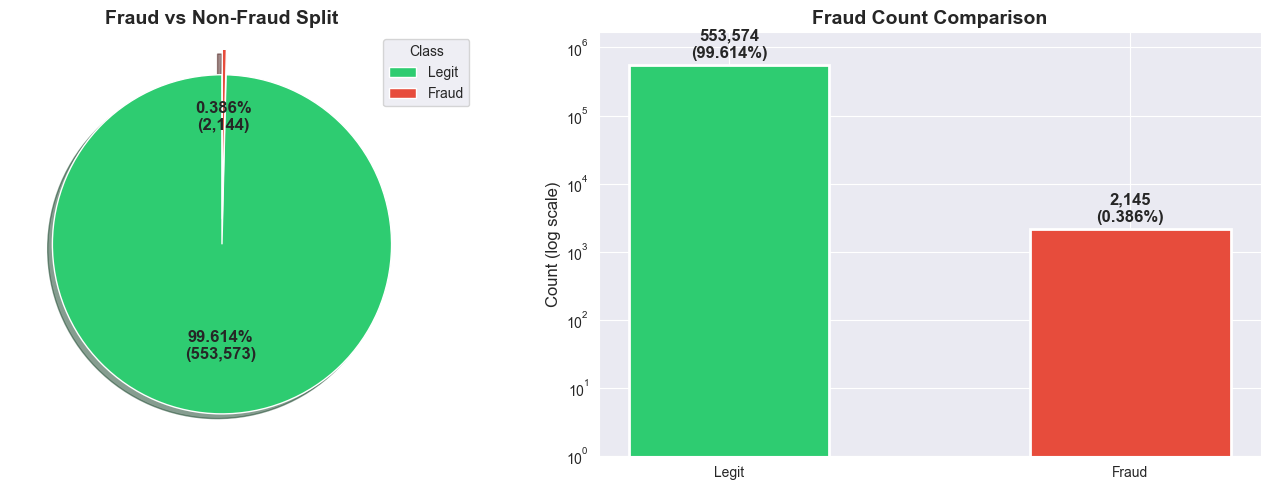

In [ ]:
# 1. Fraud vs Non-Fraud 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
counts = df['is_fraud'].value_counts()
labels = ['Legit', 'Fraud']
explode = (0, 0.15)
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=None, autopct=lambda p: f'{p:.3f}%\n({int(p*sum(counts)/100):,})',
    colors=colors, explode=explode, startangle=90, shadow=True,
    textprops={'fontsize':12, 'fontweight':'bold'},
    pctdistance=0.6, labeldistance=1.15)
ax1.legend(wedges, labels, title='Class', loc='upper right',
           bbox_to_anchor=(1.1, 1))
ax1.set_title('Fraud vs Non-Fraud Split', fontsize=14, fontweight='bold')
ax2.bar(['Legit', 'Fraud'], counts.values, color=colors, edgecolor='white',
        linewidth=2, width=0.5)
ax2.set_yscale('log')
ax2.set_ylabel('Count (log scale)', fontsize=12)
ax2.set_title('Fraud Count Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(counts.values):
    offset = v * 0.15
    ax2.text(i, v + offset, f'{v:,}\n({v/len(df)*100:.3f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(1, counts.values[0] * 3)
plt.tight_layout()
plt.show()

C:\Users\Samay\AppData\Local\Temp\ipykernel_17172\479278577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='is_fraud', y='amt', palette=colors, ax=ax1)
C:\Users\Samay\AppData\Local\Temp\ipykernel_17172\479278577.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Legit', 'Fraud'])


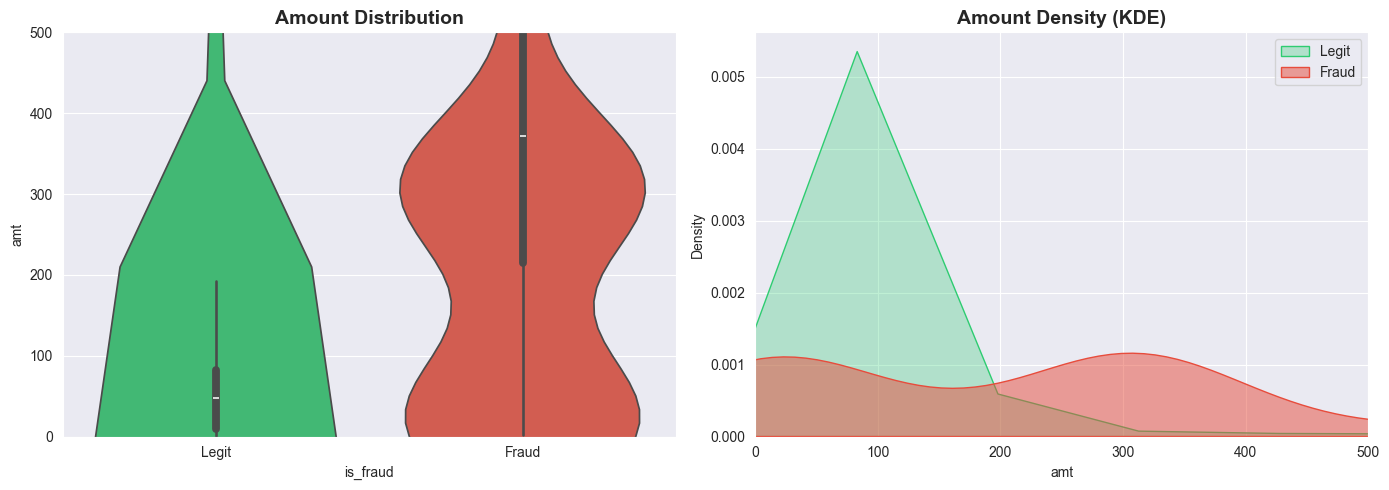

In [31]:
# 2. Transaction amount distribution by fraud 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
sns.violinplot(data=df, x='is_fraud', y='amt', palette=colors, ax=ax1)
ax1.set_xticklabels(['Legit', 'Fraud'])
ax1.set_ylim(0, 500)
ax1.set_title('Amount Distribution', fontsize=14, fontweight='bold')
sns.kdeplot(data=df[df['is_fraud']==0], x='amt', label='Legit', color=colors[0],
            fill=True, alpha=0.3, ax=ax2)
sns.kdeplot(data=df[df['is_fraud']==1], x='amt', label='Fraud', color=colors[1],
            fill=True, alpha=0.5, ax=ax2)
ax2.set_xlim(0, 500)
ax2.set_title('Amount Density (KDE)', fontsize=14, fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

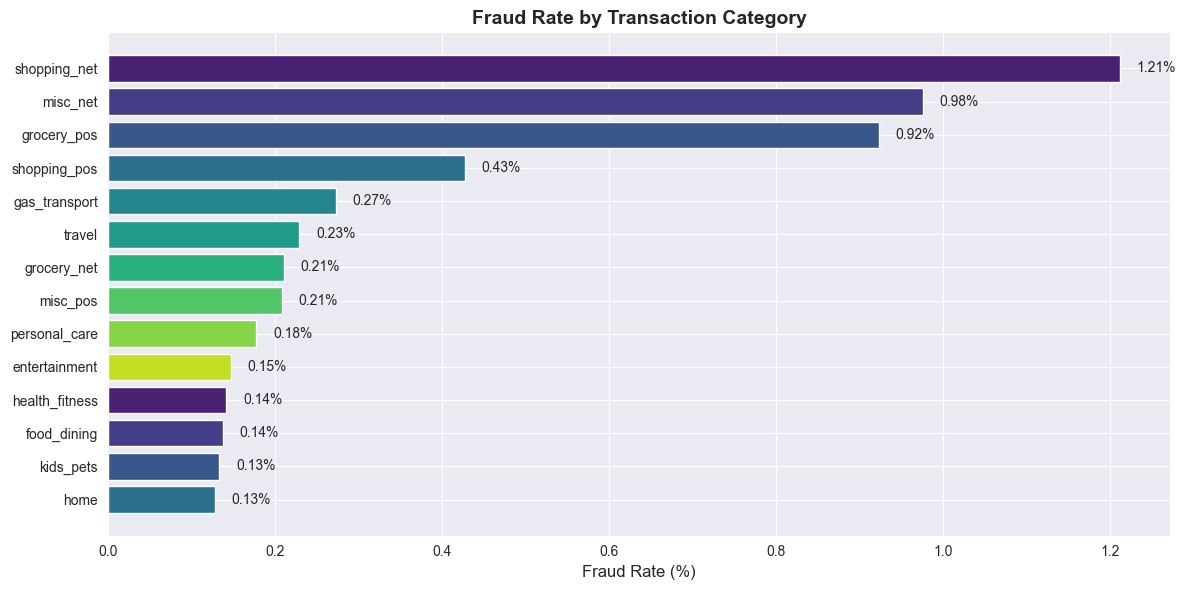

In [ ]:
# 3. Fraud rate by transaction category 
cat_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(12,6))
bars = plt.barh(cat_fraud.index, cat_fraud.values, color=palette[:len(cat_fraud)])
plt.xlabel('Fraud Rate (%)', fontsize=12)
plt.title('Fraud Rate by Transaction Category', fontsize=14, fontweight='bold')
for bar, val in zip(bars, cat_fraud.values):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

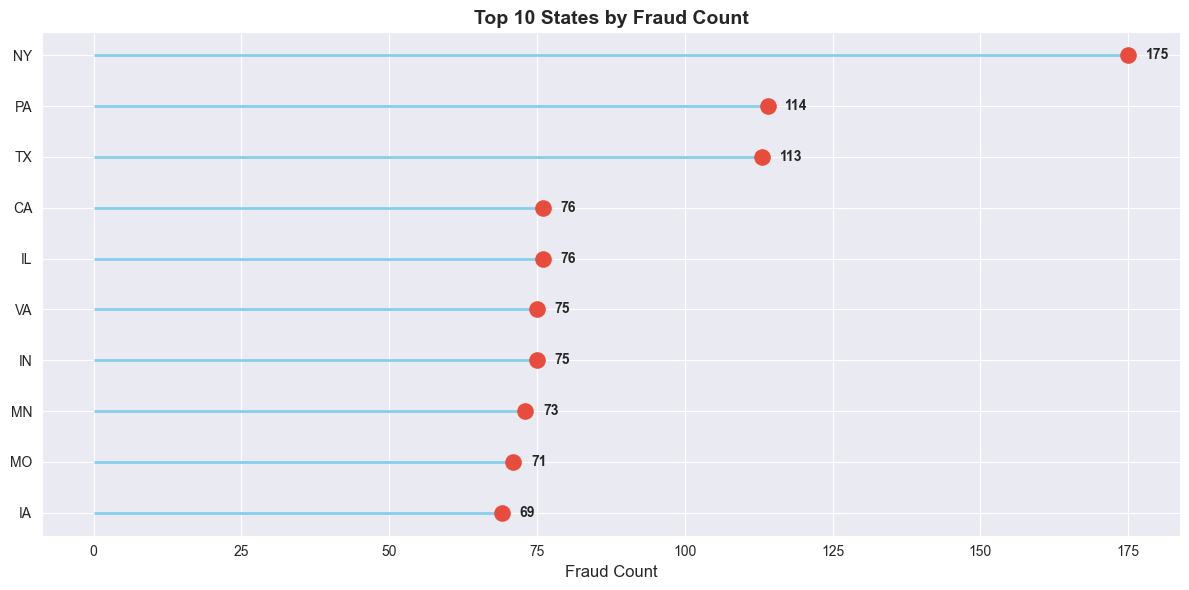

In [ ]:
# 4. Top 10 states by fraud count
state_fraud = df[df['is_fraud']==1]['state'].value_counts().head(10).sort_values()
plt.figure(figsize=(12,6))
plt.hlines(y=state_fraud.index, xmin=0, xmax=state_fraud.values,
           color='skyblue', linewidth=2)
plt.scatter(state_fraud.values, state_fraud.index, color='#e74c3c', s=120, zorder=3)
for i, v in enumerate(state_fraud.values):
    plt.text(v + 3, i, str(v), va='center', fontsize=10, fontweight='bold')
plt.xlabel('Fraud Count', fontsize=12)
plt.title('Top 10 States by Fraud Count', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

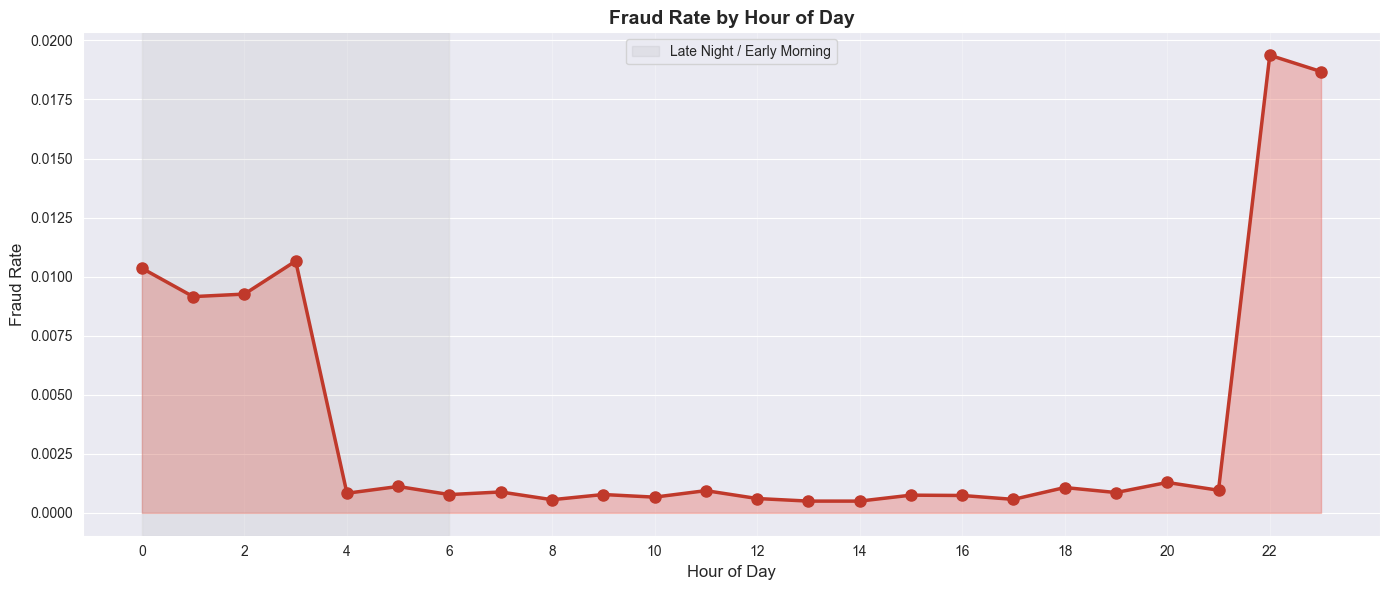

In [ ]:
# 5. Fraud by hour of day 
df['hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
hour_fraud = df.groupby('hour')['is_fraud'].mean()
plt.figure(figsize=(14,6))
plt.fill_between(hour_fraud.index, hour_fraud.values, alpha=0.3, color='#e74c3c')
plt.plot(hour_fraud.index, hour_fraud.values, 'o-', color='#c0392b',
         linewidth=2.5, markersize=8)
plt.axvspan(0, 6, alpha=0.1, color='gray', label='Late Night / Early Morning')
plt.xticks(range(0,24,2))
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Fraud Rate', fontsize=12)
plt.title('Fraud Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

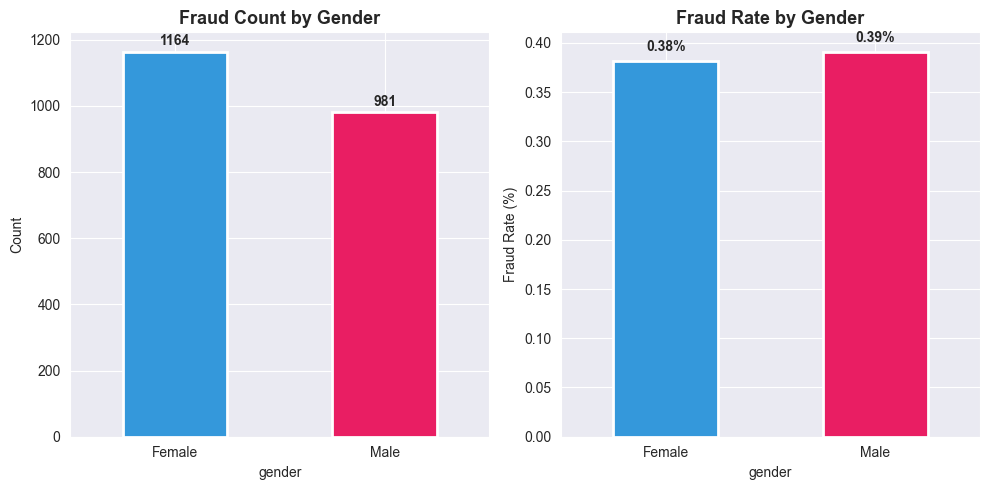

In [ ]:
# 6. Fraud by gender 
gender_fraud = df.groupby('gender')['is_fraud'].agg(['count', 'sum'])
gender_fraud['rate'] = gender_fraud['sum'] / gender_fraud['count'] * 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
gender_fraud['sum'].plot(kind='bar', ax=ax1, color=['#3498db', '#e91e63'],
                         edgecolor='white', linewidth=2)
ax1.set_title('Fraud Count by Gender', fontsize=13, fontweight='bold')
ax1.set_xticklabels(['Female', 'Male'], rotation=0)
ax1.set_ylabel('Count')
for i, v in enumerate(gender_fraud['sum']):
    ax1.text(i, v + 20, str(v), ha='center', fontweight='bold')
gender_fraud['rate'].plot(kind='bar', ax=ax2, color=['#3498db', '#e91e63'],
                          edgecolor='white', linewidth=2)
ax2.set_title('Fraud Rate by Gender', fontsize=13, fontweight='bold')
ax2.set_xticklabels(['Female', 'Male'], rotation=0)
ax2.set_ylabel('Fraud Rate (%)')
for i, v in enumerate(gender_fraud['rate']):
    ax2.text(i, v + 0.01, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# 7. Fraud transaction amount stats
fraud = df[df['is_fraud']==1]
legit = df[df['is_fraud']==0]
print(f"Total transactions: {len(df):,}")
print(f"Fraud transactions: {len(fraud):,} ({len(fraud)/len(df)*100:.2f}%)")
print(f"Legit transactions: {len(legit):,} ({len(legit)/len(df)*100:.2f}%)")
print(f"Avg fraud amount: ${fraud['amt'].mean():.2f}")
print(f"Avg legit amount: ${legit['amt'].mean():.2f}")
print(f"Median fraud amount: ${fraud['amt'].median():.2f}")
print(f"Median legit amount: ${legit['amt'].median():.2f}")
print(f"Max fraud amount: ${fraud['amt'].max():.2f}")
print(f"Min fraud amount: ${fraud['amt'].min():.2f}")

Total transactions: 555,719
Fraud transactions: 2,145 (0.39%)
Legit transactions: 553,574 (99.61%)
Avg fraud amount: $528.36
Avg legit amount: $67.61
Median fraud amount: $371.94
Median legit amount: $47.15
Max fraud amount: $1320.92
Min fraud amount: $1.78


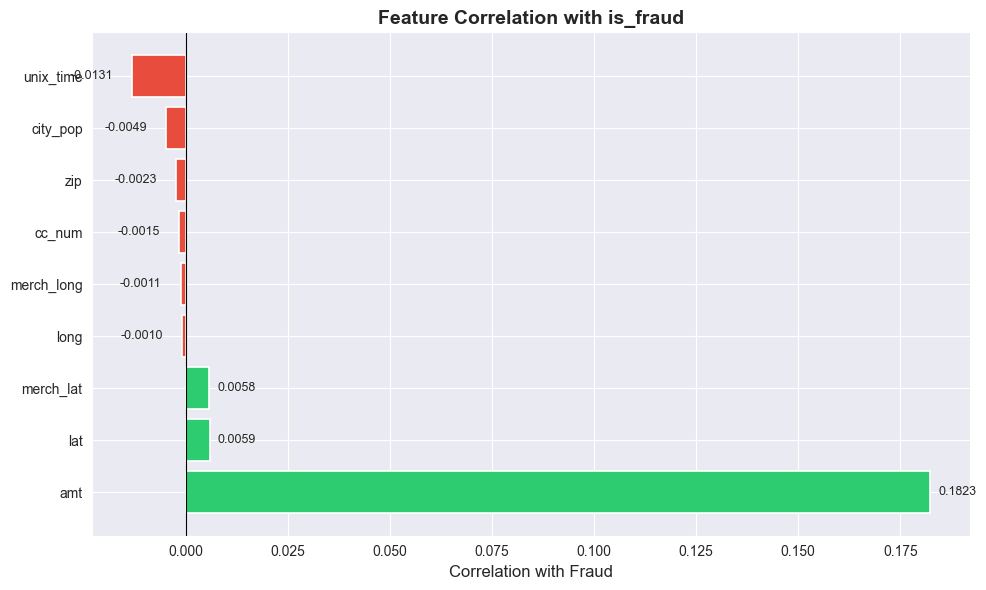

In [30]:
# 8. Full correlation heatmap of numeric features
num_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(num_df.corr(), mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 9. Feature engineering - datetime features
df['trans_date'] = pd.to_datetime(df['trans_date_trans_time'])
df['day_of_week'] = df['trans_date'].dt.day_name()
df['month'] = df['trans_date'].dt.month_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_fraud = df.groupby('day_of_week')['is_fraud'].mean() * 100
dow_fraud = dow_fraud.reindex(dow_order)
plt.figure(figsize=(10,5))
sns.barplot(x=dow_fraud.index, y=dow_fraud.values, palette='magma')
plt.title('Fraud Rate by Day of Week', fontsize=14, fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
for i, v in enumerate(dow_fraud.values):
    plt.text(i, v + 0.003, f'{v:.3f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 10. Outlier detection on transaction amount (IQR method)
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['amt'] < lower) | (df['amt'] > upper)]
fraud_outliers = outliers[outliers['is_fraud']==1]
print(f"Amount outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Fraud among outliers: {len(fraud_outliers):,} ({len(fraud_outliers)/len(outliers)*100:.2f}%)")
print(f"Fraud outliers as % of all fraud: {len(fraud_outliers)/len(fraud)*100:.2f}%")
fig, axes = plt.subplots(1,2,figsize=(12,5))
axes[0].boxplot(df['amt'], vert=False, patch_artist=True, widths=0.3,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
outlier_counts = df.groupby('is_fraud')['amt'].apply(
    lambda x: ((x < lower) | (x > upper)).sum()
)
axes[1].bar(['Legit', 'Fraud'], outlier_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('Outliers by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(outlier_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 11. Simple fraud prediction model (Logistic Regression)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
features = ['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']
X = df[features]
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,
                                                    stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
print("="*55)
print("FRAUD DETECTION MODEL - LOGISTIC REGRESSION".center(55))
print("="*55)
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 12. Feature importance from the model
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=True)
plt.figure(figsize=(10,6))
colors_coef = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef,
         edgecolor='white', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Importance (Logistic Regression)', fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(coef_df.iterrows()):
    val = row['Coefficient']
    plt.text(val + 0.02 if val > 0 else val - 0.08, i, f'{val:.4f}',
             va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# 13. Key Insights Summary
fraud = df[df['is_fraud']==1]
legit = df[df['is_fraud']==0]
cat_fraud_sorted = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
state_fraud_sorted = df[df['is_fraud']==1]['state'].value_counts()
print("="*60)
print("KEY INSIGHTS - FRAUD DETECTION ANALYSIS".center(60))
print("="*60)
print(f"\n1. IMBALANCE: Only {len(fraud)/len(df)*100:.3f}% of transactions are fraudulent.")
print(f"2. AMOUNT: Fraud avg = ${fraud['amt'].mean():.2f} vs Legit avg = ${legit['amt'].mean():.2f}")
print(f"3. HIGH-RISK CATEGORY: '{cat_fraud_sorted.index[0]}' has highest fraud rate at {cat_fraud_sorted.iloc[0]*100:.2f}%")
print(f"4. HIGH-RISK STATE: '{state_fraud_sorted.index[0]}' has the most fraud cases ({state_fraud_sorted.iloc[0]}).")
print(f"5. TIME: Fraud rate peaks in late night/early morning hours (12 AM - 6 AM).")
print(f"6. GENDER: Fraud rates are very similar between genders.")
upper_bound = df['amt'].quantile(0.75) + 1.5 * (df['amt'].quantile(0.75) - df['amt'].quantile(0.25))
fraud_outliers_count = len(fraud[fraud['amt'] > upper_bound])
print(f"7. OUTLIERS: {fraud_outliers_count} fraud cases are amount outliers.")
print(f"8. TOP PREDICTOR: 'amt' (transaction amount) shows the strongest correlation with fraud.")
print("="*60)
print("RECOMMENDATIONS".center(60))
print("="*60)
print("\n- Flag high-value transactions (>$200) during late night hours (12 AM - 6 AM).")
print(f"- Focus monitoring on '{cat_fraud_sorted.index[0]}' category.")
print("- Investigate transactions flagged as statistical outliers.")
print("- Monitor states with disproportionately high fraud counts.")

          KEY INSIGHTS - FRAUD DETECTION ANALYSIS           

1. IMBALANCE: Only 0.386% of transactions are fraudulent.
2. AMOUNT: Fraud avg = $528.36 vs Legit avg = $67.61
3. HIGH-RISK CATEGORY: 'shopping_net' has highest fraud rate at 1.21%
4. HIGH-RISK STATE: 'NY' has the most fraud cases (175).
5. TIME: Fraud rate peaks in late night/early morning hours (12 AM - 6 AM).
6. GENDER: Fraud rates are very similar between genders.
7. OUTLIERS: 1613 fraud cases are amount outliers.
8. TOP PREDICTOR: 'amt' (transaction amount) shows the strongest correlation with fraud.
                      RECOMMENDATIONS                       

- Flag high-value transactions (>$200) during late night hours (12 AM - 6 AM).
- Focus monitoring on 'shopping_net' category.
- Deploy a fraud detection model (Logistic Regression) for real-time scoring.
- Investigate transactions flagged as statistical outliers.
- Monitor states with disproportionately high fraud counts.
